In [1]:
import pandas as pd
import json

In [2]:
# Load your cleaned dataset
det = pd.read_csv("detentions_2021_25.csv")

# Load offense classification (discretionary or serious)
with open("offenses_mapping.json", "r") as f:
    offense_mapping = json.load(f)


In [3]:

# Merge discretionary classification to the detentions dataframe
det['discretionary'] = det['offense'].map(lambda x: offense_mapping.get(x, {}).get('discretionary', None))
det['category'] = det['offense'].map(lambda x: offense_mapping.get(x, {}).get('category', None))


In [4]:

# Add category labels based on nationality and discretionary status
def categorize(row):
    if row['nat'] == 'Chilena' and row['discretionary'] == 1:
        return 'Chilean Discretionary'
    elif row['nat'] == 'Chilena' and row['discretionary'] == 0:
        return 'Chilean Non-Discretionary'
    elif row['nat'] == 'Venezolana' and row['discretionary'] == 1:
        return 'Venezuelan Discretionary'
    elif row['nat'] == 'Venezolana' and row['discretionary'] == 0:
        return 'Venezuelan Non-Discretionary'
    else:
        return None

det['category_label'] = det.apply(categorize, axis=1)


/var/folders/rz/6xj51b7927n_30r809vmztfh0000gn/T/ipykernel_53176/3674389477.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=det, x='category_label', y='n_det', jitter=True, palette='Set1', size=4)


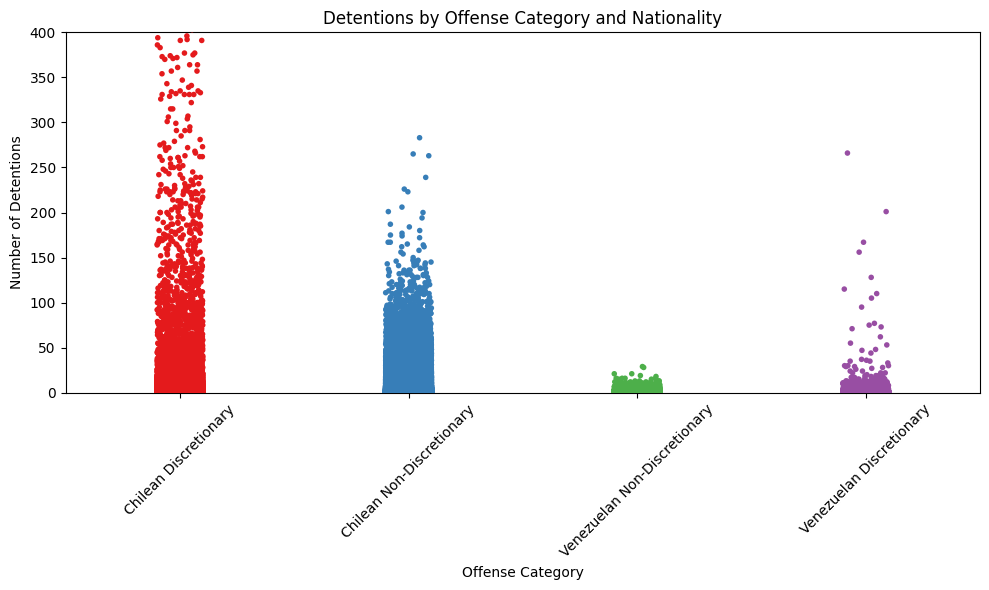

  comuna        nat                                            offense  \
0  ARICA  Boliviana  Infringir normas higiénicas y de salubridad ar...   
1  ARICA  Boliviana                                       Riña pública   
2  ARICA    Chilena  Conducción bajo la influencia de alcohol con o...   
3  ARICA    Chilena                      Conducción estado de ebriedad   
4  ARICA    Chilena                                        Receptación   

              category_label  
0                       None  
1                       None  
2      Chilean Discretionary  
3      Chilean Discretionary  
4  Chilean Non-Discretionary  


In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# Prepare the data for the plot (we’ll use 'category_label' and 'n_det')
plt.figure(figsize=(10, 6))

# Create the strip plot
sns.stripplot(data=det, x='category_label', y='n_det', jitter=True, palette='Set1', size=4)

# Add titles and labels
plt.title("Detentions by Offense Category and Nationality")
plt.xlabel("Offense Category")
plt.ylabel("Number of Detentions")
plt.xticks(rotation=45)  # Rotate x labels for readability

# set the y-axis limit to 400
plt.ylim(0, 400)

# Show the plot
plt.tight_layout()
plt.show()

# Check the new category labels
print(det[['comuna', 'nat', 'offense', 'category_label']].head())


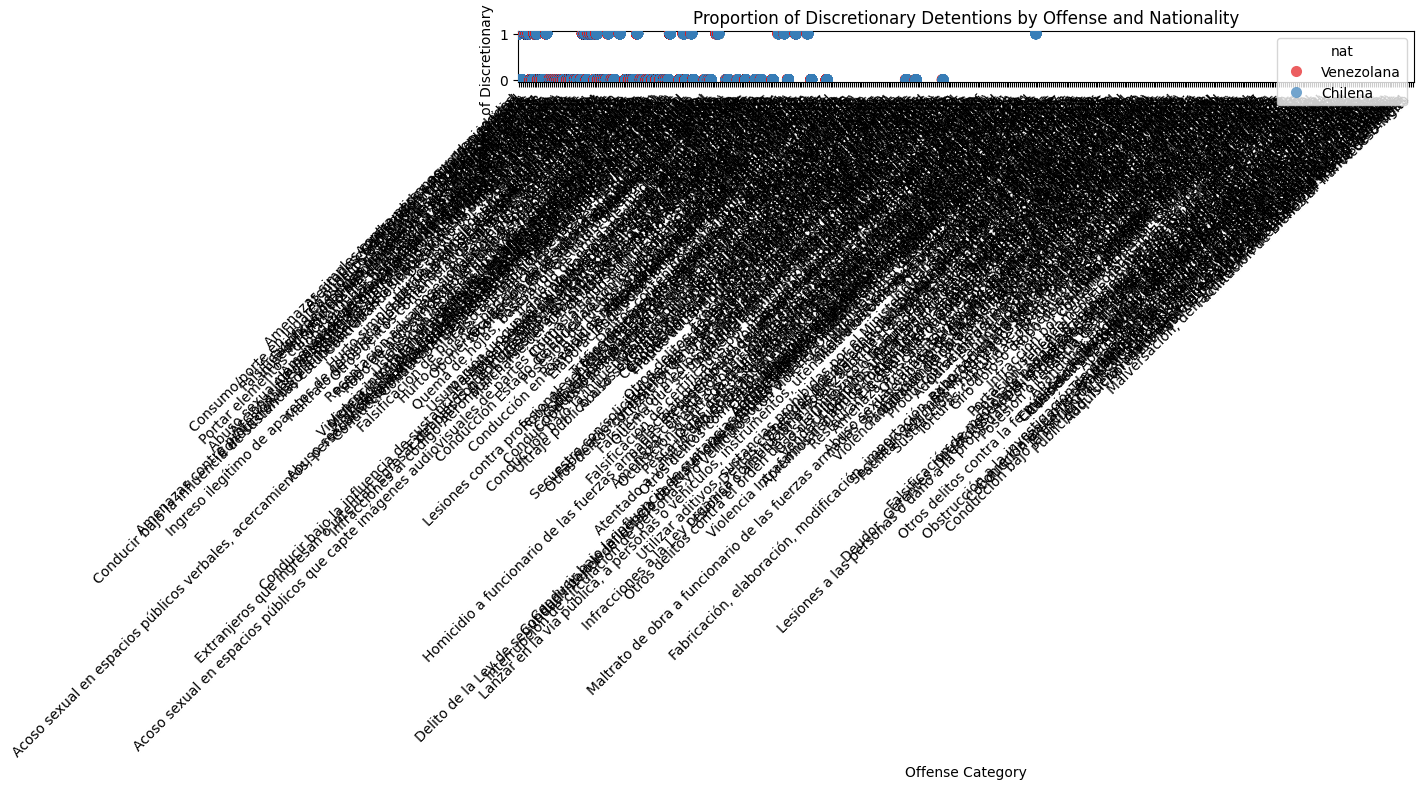

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Filter the data for Venezuelans and Chilens
venezuelans = det[det['nat'] == 'Venezolana']
chilens = det[det['nat'] == 'Chilena']

# Step 2: Calculate the proportion of discretionary detentions for each offense and region
# For Venezuelans
venezuelan_proportion = venezuelans.groupby(['comuna', 'offense'])['discretionary'].mean().reset_index()
venezuelan_proportion['nat'] = 'Venezolana'

# For Chilens
chilen_proportion = chilens.groupby(['comuna', 'offense'])['discretionary'].mean().reset_index()
chilen_proportion['nat'] = 'Chilena'

# Combine the two datasets
proportion_data = pd.concat([venezuelan_proportion, chilen_proportion], ignore_index=True)

# Step 3: Create the strip plot with jitter
plt.figure(figsize=(14, 8))

# Strip plot to show proportions as dots
sns.stripplot(data=proportion_data, 
              x='offense', 
              y='discretionary', 
              hue='nat', 
              palette='Set1', 
              jitter=True, 
              dodge=True, 
              size=8, 
              alpha=0.7)

# Add titles and labels
plt.title("Proportion of Discretionary Detentions by Offense and Nationality")
plt.xlabel("Offense Category")
plt.ylabel("Proportion of Discretionary Detentions")
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability

# Display the plot
plt.tight_layout()
plt.show()


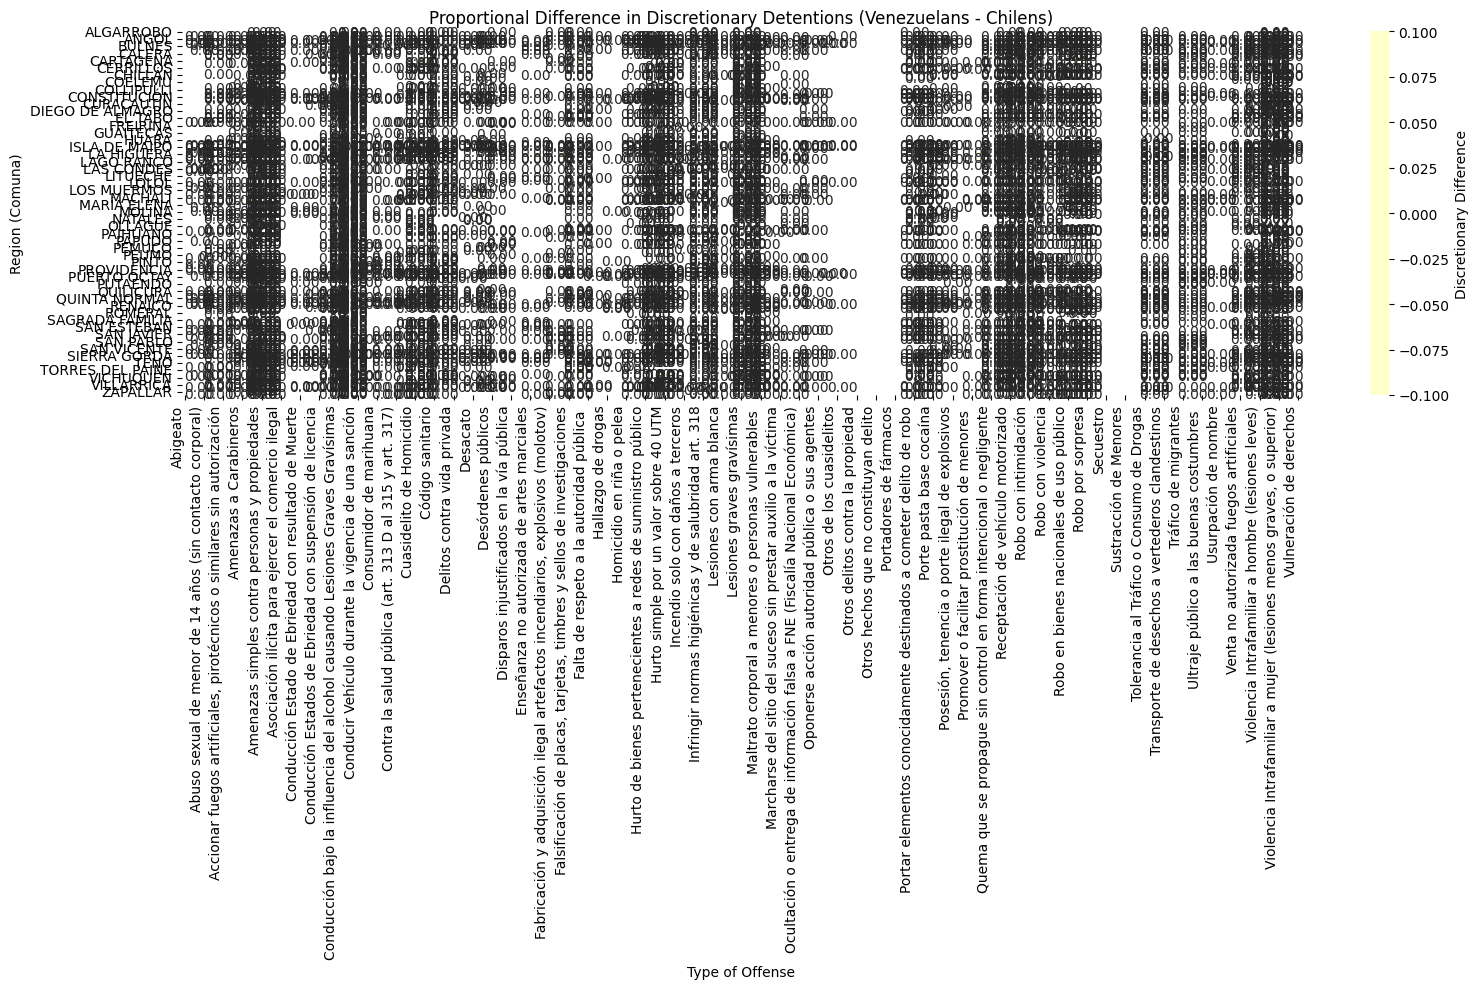

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Step 1: Filter the data for Venezuelans and Chilens
venezuelans = det[det['nat'] == 'Venezolana']
chilens = det[det['nat'] == 'Chilena']

# Step 2: Calculate the proportion of discretionary detentions for each offense and region
# For Venezuelans
venezuelan_proportion = venezuelans.groupby(['comuna', 'offense'])['discretionary'].mean().reset_index()
venezuelan_proportion['nat'] = 'Venezolana'

# For Chilens
chilen_proportion = chilens.groupby(['comuna', 'offense'])['discretionary'].mean().reset_index()
chilen_proportion['nat'] = 'Chilena'

# Merge the two datasets on comuna and offense
merged_proportions = pd.merge(venezuelan_proportion, chilen_proportion, on=['comuna', 'offense'], suffixes=('_ven', '_chi'))

# Step 3: Calculate the difference in proportions (Venezuelans - Chilens)
merged_proportions['discretionary_diff'] = merged_proportions['discretionary_ven'] - merged_proportions['discretionary_chi']

# Step 4: Pivot the data to create a matrix for the heatmap
heatmap_data = merged_proportions.pivot(index='comuna', columns='offense', values='discretionary_diff')

# Step 5: Create the heatmap with adjusted size and label rotation
plt.figure(figsize=(16, 10))  # Increased figure size for better readability

# Create the heatmap
sns.heatmap(heatmap_data, cmap='YlOrRd', center=0, annot=True, fmt='.2f', linewidths=0.5, 
            cbar_kws={'label': 'Discretionary Difference'}, square=False)

# Rotate the x-axis and y-axis labels for better readability
plt.xticks(rotation=90, ha='right')
plt.yticks(rotation=0)  # Keep the y-axis labels horizontal for readability

# Add titles and labels
plt.title("Proportional Difference in Discretionary Detentions (Venezuelans - Chilens)")
plt.xlabel("Type of Offense")
plt.ylabel("Region (Comuna)")

# Display the plot with tight layout to prevent overlapping
plt.tight_layout()
plt.show()
